# Final Project

Spring 2026 Data Science Project

**Contributions:**

A: Whole group decided on this idea for metallic and non-metallic products with their quantity and value.
B & C:

- Eric contributed to Metallic/Non-metallic quantity product comparisons.
- Jon worked on the metallic/non-metallic value comparisons.
- Tejas worked on the annual mineral quantity vs value datasets.

Minerals are an important part of Canada's economy, because they are used in construction, manufacturing, technology, trade, and a bunch of other industries. However, not all minerals contribute to the economy in the same way. Some minerals may be produced in very large quantities, but have lower shipment values, while others can have few quantities, but much higher value. As a group, we hope to take these datasets about mineral production in order to better understand how metallic and non-metallic minerals differ in production quality, shipment value, and overall economic contribution.

**This project is guided by three main questions.**

The first being "Do metallic and non-metallic minerals differ significantly in their production quantities?". Comparing distributions helps show whether they should be analyzed together or treated as separate parts due to their differing production scales within the Canadian mining sector.

The second is "Is there a strong relationship between mineral production quantity and shipment value?". Apart from whether a material is rare or not, this question matters because it tests whether producing more of a mineral necessarily means generating more economic value. If quantity and value are weakly related, then other factors such as supply/demand, price per unit, industrial usage may be a more important factor.

The final is "Has Canada's overall mineral value changed significantly in recent years compared to 2019?". Setting aside the obvious yes/no answer, this matters because it helps identify which minerals have gained importance over the years and whether this can be evaluated in a statistically meaningful way.

Data processing:

In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.ticker import ScalarFormatter, FuncFormatter
from scipy import stats

from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import r2_score, mean_squared_error
from sklearn.model_selection import train_test_split

### Quantity and value of metallic materials (Monthly)
(Jon)
tracks monthly production quantities and shipment values for metallic minerals across Canada

In [ ]:
metallic_val_df = pd.read_csv('Metallic Value.csv', skiprows=10)
metallic_val_df = metallic_val_df.iloc[:-20]
metallic_val_df.replace({'..': float('nan'), 'x': float('nan')}, inplace=True)

metallic_val_df = metallic_val_df.melt(
    id_vars='Products',
    var_name='Month',
    value_name='Value'
)
metallic_val_df['Value'] = pd.to_numeric(metallic_val_df['Value'].str.replace(',', ''))
metallic_val_df.dropna(inplace=True)
metallic_val_df = metallic_val_df[metallic_val_df['Value'] > 0]

metallic_mean = metallic_val_df['Value'].mean()
metallic_mean

np.float64(676947726.5590551)

In [ ]:
non_metallic_val_df = pd.read_csv('Non-Metallic Value.csv', skiprows=10)
non_metallic_val_df = non_metallic_val_df.iloc[:-14]
non_metallic_val_df.replace({'..': float('nan'), 'x': float('nan')}, inplace=True)

non_metallic_val_df = non_metallic_val_df.melt(
    id_vars='Products',
    var_name='Month',
    value_name='Value'
)
non_metallic_val_df['Value'] = pd.to_numeric(non_metallic_val_df['Value'].str.replace(',', ''))
non_metallic_val_df.dropna(inplace=True)
non_metallic_val_df = non_metallic_val_df[non_metallic_val_df['Value'] > 0]

non_metallic_mean = non_metallic_val_df['Value'].mean()
non_metallic_mean

np.float64(131743784.64102565)

Eric Checkpoint 2: Combined metallic and non metallic (monthly)

In [ ]:
def load_statcan_monthly_quantity(filename, category_name):
    df = pd.read_csv(filename, skiprows=8, header=1) # format of the csv file has some garbage lines for the first 8 rows at the top
    df["Products"] = df["Products"].ffill() # some products are NaN but they really belong to the same Product until a fresh one is listed so this just carries them down
    df = df.replace(["..", "x"], np.nan) # actually does the replacing

    df = df.melt(
        id_vars = ["Products", "Variables"],
        var_name = "REF_DATE", # month columns become reference date
        value_name = "VALUE" # their actual entries will become the value
    )

    df = df.dropna(subset=["VALUE"]).copy() # drop missing values

    df["VALUE"] = df["VALUE"].astype(str).str.replace(",", "", regex=False) # remove commas from "numbers"
    df["VALUE"] = pd.to_numeric(df["VALUE"], errors="coerce") # convert value column (string) to numbers
    df = df.dropna(subset=["VALUE"]).copy() # drop rows where value failed to convert to number

    df["REF_DATE"] = pd.to_datetime(df["REF_DATE"], format="%B %Y", errors="coerce") # convert date strings to actual date time objects
    df = df.dropna(subset=["REF_DATE"]).copy() # dropping invalid dates

    df["Unit"] = df["Products"].str.extract(r"\((.*?)\)") # extract unit of measurement (metric tonnes)
    df["Product_Name"] = ( # creates a cleaner product name by removing the unit in parantheses, trailing numbers, and whitespace (that appears)
        df["Products"].str.replace(r"\s*\(.*?\)", "", regex=True)
        .str.replace(r"\s+\d+$", "", regex=True).str.strip()
    )

    df["Category"] = category_name # this is just for non-metallic vs metallic naming
    return df

# Quantity and value of annual mineral produciton (tejas)

In [5]:
df_qty = pd.read_csv('canada_annual_quantities.csv', skiprows = 8, header = 1)
df_val = pd.read_csv('canada_annual_values.csv', skiprows = 9, header = 1)

df_qty = df_qty.replace(['..', 'x'], np.nan)
df_val = df_val.replace(['..', 'x'], np.nan)

In [6]:
years = ['2019', '2020', '2021', '2022', '2023', '2024', '2025']
quantities = []
values = []

for year in years:
    qty = pd.to_numeric(df_qty[year].astype(str).str.replace(',', '').str.replace('p', ''), errors = 'coerce').sum()
    val = pd.to_numeric(df_val[year].astype(str).str.replace(',', '').str.replace('p', ''), errors = 'coerce').sum()
    quantities.append(qty)
    values.append(val)

summary = pd.DataFrame({
    'Year': [int(y) for y in years],
    'Total_Quantity': quantities,
    'Total_Value_CAD_1000s': values
})

print(summary)

   Year  Total_Quantity  Total_Value_CAD_1000s
0  2019    2.165204e+09            158631345.0
1  2020    2.321877e+09            163015135.0
2  2021    2.566518e+09            191282564.0
3  2022    2.774921e+09            223359859.0
4  2023    2.705729e+09            197943726.0
5  2024    3.021890e+09            193909864.0
6  2025    1.926167e+09            180875883.0


Metallic and non metallic values (jon)

In [ ]:
metallic_val_df = pd.read_csv('Metallic Value.csv', skiprows=10)
metallic_val_df = metallic_val_df.iloc[:-20]
metallic_val_df.replace({'..': float('nan'), 'x': float('nan')}, inplace=True)

metallic_val_df = metallic_val_df.melt(
    id_vars='Products',
    var_name='Month',
    value_name='Value'
)
metallic_val_df['Value'] = pd.to_numeric(metallic_val_df['Value'].str.replace(',', ''))
metallic_val_df.dropna(inplace=True)
metallic_val_df = metallic_val_df[metallic_val_df['Value'] > 0]

metallic_mean = metallic_val_df['Value'].mean()
metallic_mean

np.float64(676947726.5590551)

In [ ]:
non_metallic_val_df = pd.read_csv('Non-Metallic Value.csv', skiprows=10)
non_metallic_val_df = non_metallic_val_df.iloc[:-14]
non_metallic_val_df.replace({'..': float('nan'), 'x': float('nan')}, inplace=True)

non_metallic_val_df = non_metallic_val_df.melt(
    id_vars='Products',
    var_name='Month',
    value_name='Value'
)
non_metallic_val_df['Value'] = pd.to_numeric(non_metallic_val_df['Value'].str.replace(',', ''))
non_metallic_val_df.dropna(inplace=True)
non_metallic_val_df = non_metallic_val_df[non_metallic_val_df['Value'] > 0]

non_metallic_mean = non_metallic_val_df['Value'].mean()
non_metallic_mean

np.float64(131743784.64102565)

In [ ]:
metallic_df = load_statcan_monthly_quantity("1610001901-eng.csv", "Metallic")
nonmetallic_df = load_statcan_monthly_quantity("1610002001-eng.csv", "Non-metallic")

combined_df = pd.concat([metallic_df, nonmetallic_df], ignore_index=True)

quantity_df = combined_df[combined_df["Unit"].str.contains("metric tonnes", case=False, na=False)].copy()

produced_df = quantity_df[quantity_df["Variables"].str.contains("produced", case=False, na=False)].copy()

combined_produced_df = produced_df

# Average monthly production by category (eric)

Average monthly quantity produced by category:
Category
Metallic        948986.847525
Non-metallic    381142.471831
Name: VALUE, dtype: float64


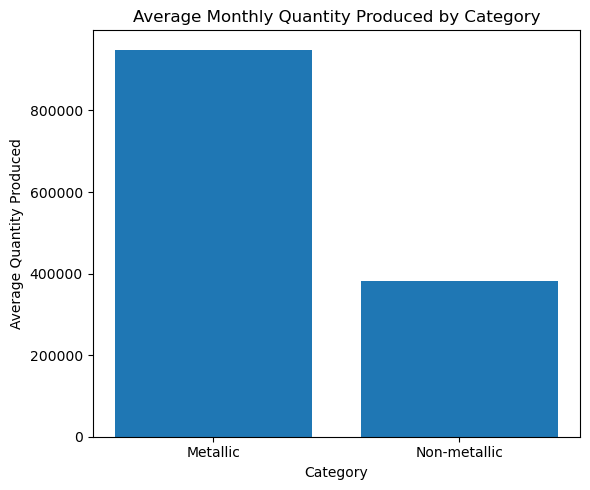

In [ ]:
category_avg = ( # average monthly production for each category calculation
    produced_df.groupby("Category")["VALUE"].mean().sort_values(ascending=False)
)

print("Average monthly quantity produced by category:") # displaying averages for reference
print(category_avg)

plt.figure(figsize=(6, 5)) # plot stuff
plt.bar(category_avg.index, category_avg.values)
plt.title("Average Monthly Quantity Produced by Category")
plt.xlabel("Category")
plt.ylabel("Average Quantity Produced")
plt.tight_layout()
plt.show()

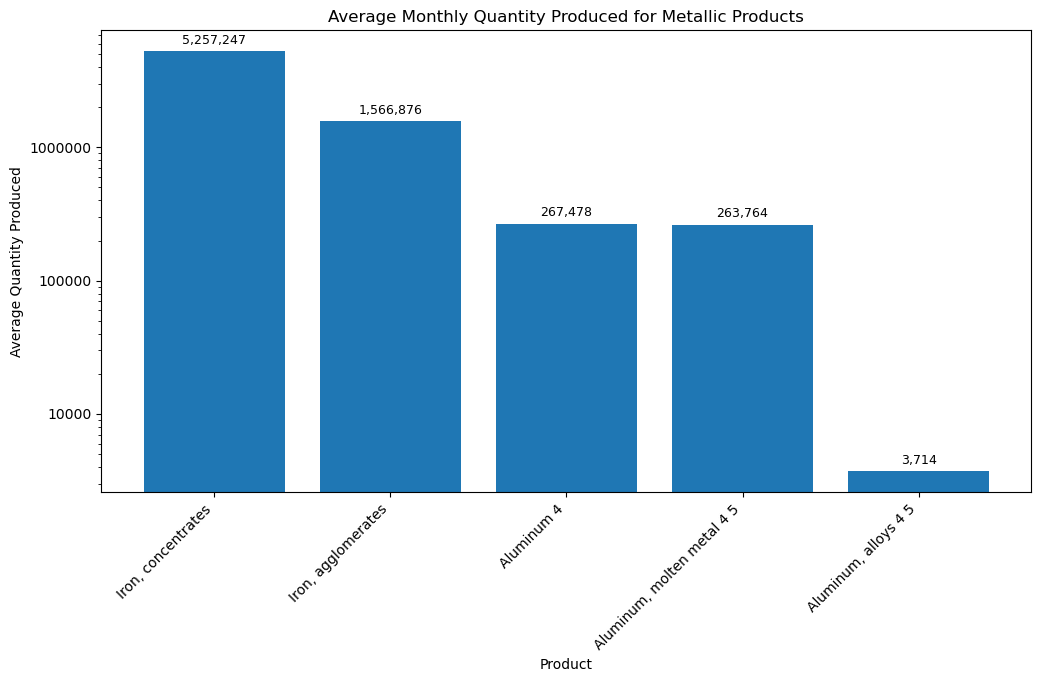

In [ ]:
metallic_avg = ( # compute for average monthly production for each metallic product
    produced_df[produced_df["Category"] == "Metallic"].groupby("Product_Name")["VALUE"].mean().sort_values(ascending=False)
)

metallic_positive = metallic_avg[metallic_avg > 0] # keep positive average values (doesnt make sense to produce a negative amount)

plt.figure(figsize=(12, 6))
bars = plt.bar(metallic_positive.index, metallic_positive.values)

plt.yscale("log") # log scale cause it wasn't really showing all the differences in a natural way
plt.title("Average Monthly Quantity Produced for Metallic Products")
plt.xlabel("Product")
plt.ylabel("Average Quantity Produced")
plt.xticks(rotation=45, ha="right")

# formats y-axis as regular numbers instead of using scientific notation
ax = plt.gca()
ax.yaxis.set_major_formatter(ScalarFormatter())
ax.ticklabel_format(style="plain", axis="y")

# add average value as text above each bar (not entirely sure if this is needed?)
for bar in bars:
    height = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        height * 1.08,
        f"{height:,.0f}",
        ha="center",
        va="bottom",
        fontsize = 9
    )

plt.tight_layout
plt.show()

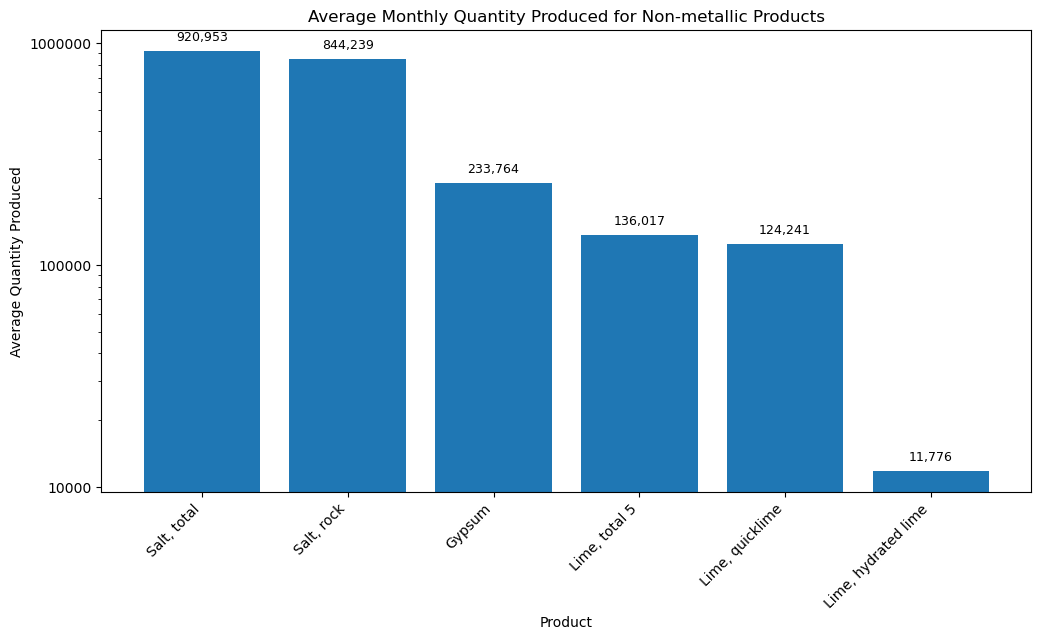

In [ ]:
nonmetallic_avg = ( # compute for average monthly production for each nonmetallic product
    produced_df[produced_df["Category"] == "Non-metallic"].groupby("Product_Name")["VALUE"].mean().sort_values(ascending=False)
)

nonmetallic_positive = nonmetallic_avg[nonmetallic_avg > 0] # keep positive average values (doesnt make sense to produce a negative amount)

plt.figure(figsize=(12, 6))
bars = plt.bar(nonmetallic_positive.index, nonmetallic_positive.values)

plt.yscale("log") # log scale cause it wasn't really showing all the differences in a natural way
plt.title("Average Monthly Quantity Produced for Non-metallic Products")
plt.xlabel("Product")
plt.ylabel("Average Quantity Produced")
plt.xticks(rotation=45, ha="right")

# formats y-axis as regular numbers instead of using scientific notation
ax = plt.gca()
ax.yaxis.set_major_formatter(ScalarFormatter())
ax.ticklabel_format(style="plain", axis="y")

# add average value as text above each bar (not entirely sure if this is needed?)
for bar in bars:
    height = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        height * 1.08,
        f"{height:,.0f}",
        ha="center",
        va="bottom",
        fontsize = 9
    )

plt.tight_layout
plt.show()

Annual quantity vs Value Correlation (tejas)

In [ ]:
correlation = summary['Total_Quantity'].corr(summary['Total_Value_CAD_1000s'])
print(f"Pearson correlation: {correlation:.3f}")

Pearson correlation: 0.663


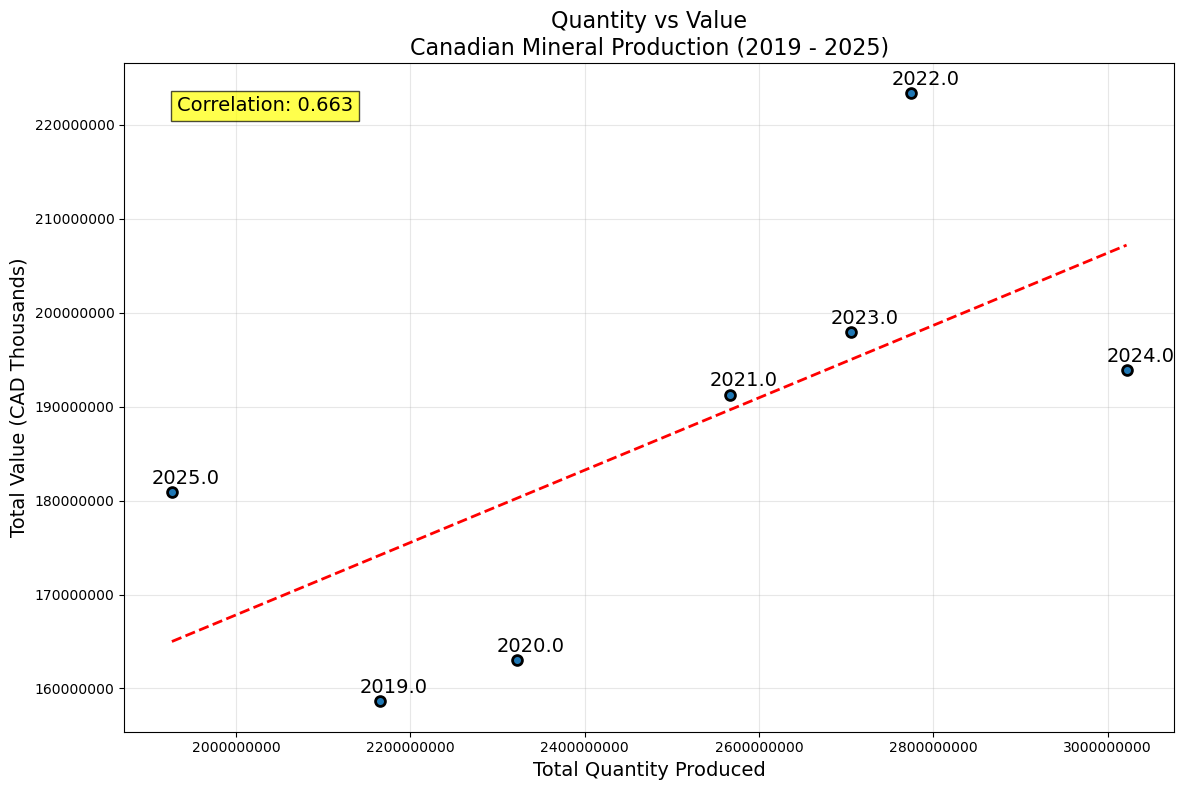

In [ ]:
plt.figure(figsize = (12, 8))

plt.scatter(summary['Total_Quantity'], summary['Total_Value_CAD_1000s'], s = 50, edgecolors = 'black', linewidth = 2)

for idx, row in summary.iterrows():
    plt.annotate(
        str(row['Year']),
        (row['Total_Quantity'], row['Total_Value_CAD_1000s']),
        xytext=(10, 10),
        textcoords='offset points',
        fontsize=14,
        ha='center',
        va='center'
    )
z  =  np.polyfit(summary['Total_Quantity'], summary['Total_Value_CAD_1000s'], 1)
p  =  np.poly1d(z)

x_line  =  np.linspace(summary['Total_Quantity'].min(), summary['Total_Quantity'].max(), 50)
plt.plot(x_line, p(x_line), 'r--', linewidth = 2)

plt.text(0.05, 0.95, f'Correlation: {correlation:.3f}', transform = plt.gca().transAxes,
         fontsize = 14, bbox = dict(facecolor = 'yellow', alpha = 0.7), verticalalignment = 'top')

plt.ticklabel_format(style = 'plain', axis = 'both')

plt.xlabel('Total Quantity Produced', fontsize = 14)
plt.ylabel('Total Value (CAD Thousands)', fontsize = 14)
plt.title('Quantity vs Value\nCanadian Mineral Production (2019 - 2025)', fontsize = 16)

plt.grid(True, alpha = 0.3)
plt.tight_layout()
plt.show()

Metallic vs non metallic value comparison (jon)

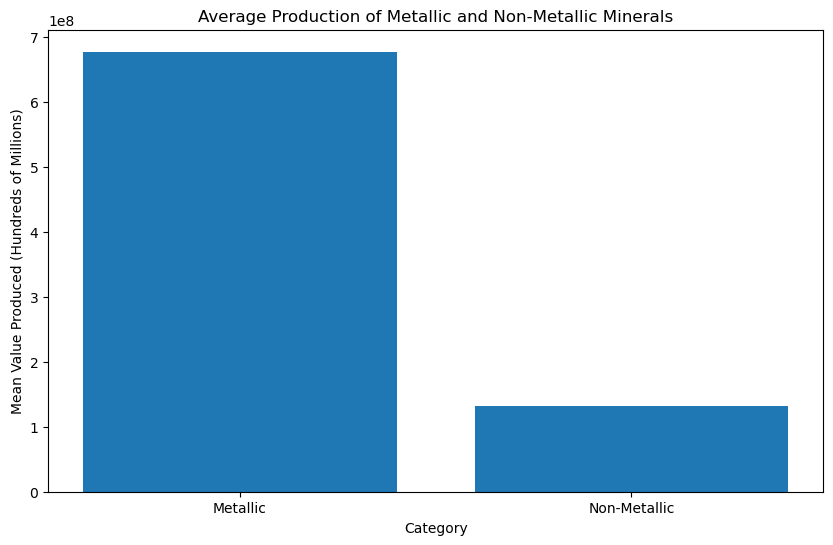

In [ ]:
ids = ['Metallic', 'Non-Metallic']
mean_values = [metallic_mean, non_metallic_mean]

plt.figure(figsize=(10, 6))
plt.bar(ids, mean_values)
plt.title('Average Production of Metallic and Non-Metallic Minerals')
plt.xlabel('Category')
plt.ylabel('Mean Value Produced (Hundreds of Millions)')
plt.yticks
plt.show()

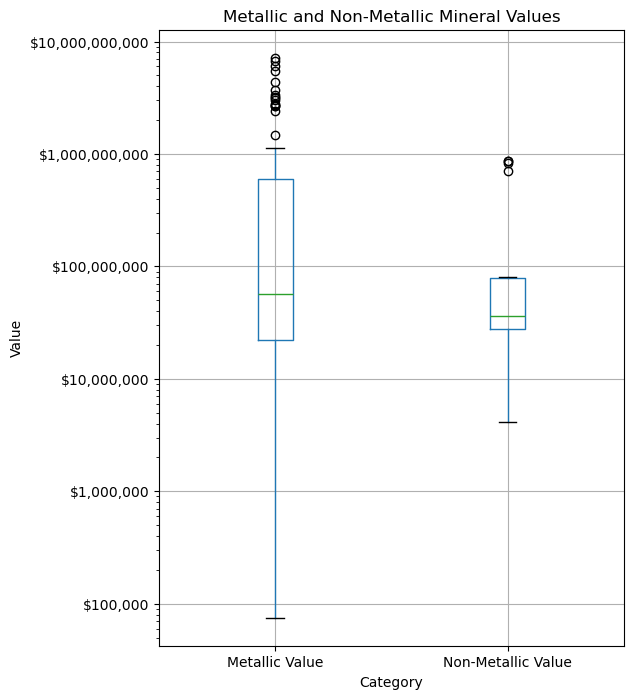

In [ ]:
values_df = pd.DataFrame()
values_df['Metallic Value'] = metallic_val_df['Value']
values_df['Non-Metallic Value'] = non_metallic_val_df['Value']
boxplot = values_df.boxplot(column=['Metallic Value', 'Non-Metallic Value'], figsize=(6, 8))
plt.title('Metallic and Non-Metallic Mineral Values')
plt.xlabel('Category')
plt.ylabel('Value')
plt.yscale('log')
plt.gca().yaxis.set_major_formatter(FuncFormatter(lambda x, _: f'${x:,.0f}'))
plt.show()

## Conclusion 1: Metallic minerals are produced in different quantities than non metallic materials

**Mann-Whitney U test** to determine whether difference is statistically significant

Null hypothesis: Distribution is same for metallic and non metallic minerals

Alternative hypothesis: Distribution is different

In [ ]:
metallic_values = combined_produced_df[combined_produced_df["Category"] == "Metallic"]["VALUE"].dropna()
nonmetallic_values = combined_produced_df[combined_produced_df["Category"] == "Non-metallic"]["VALUE"].dropna()

print(f"Metallic observations: {len(metallic_values)}")
print(f"Non-metallic observations: {len(nonmetallic_values)}")
print(f"\nMetallic median: {metallic_values.median():,.0f}")
print(f"Non-metallic median: {nonmetallic_values.median():,.0f}")
print(f"Metallic mean: {metallic_values.mean():,.0f}")
print(f"Non-metallic mean: {nonmetallic_values.mean():,.0f}")

# test
u_stat, p_value = stats.mannwhitneyu(metallic_values, nonmetallic_values, alternative='two-sided')
print(f"\nMann-Whitney U statistic: {u_stat:,.0f}")
print(f"p-value: {p_value:.6f}")




Metallic observations: 505
Non-metallic observations: 426

Metallic median: 238,002
Non-metallic median: 157,898
Metallic mean: 948,987
Non-metallic mean: 381,142

Mann-Whitney U statistic: 84,898
p-value: 0.000000


Due to p-value under 0.05, we can conclude that the difference in production quantity distributions of metallic and non-metallic minerals are significant, which means that the two categories represent different scales of production in Canada's mining sector.

## Conclusion 2: Production quantity and shipment value are not strongly correlated among metallic minerals

**Pearson correlation w/ hypothesis test** to determine whether statistically significant

Null hypothesis: No linear association between avg monthly quantity and avg monthly value (p = 0)

Alternative hypothesis: There is linear association (p != 0)

In [87]:
# Using tejas data, match quantity produced with value per mineral
import re

df_qty['Products'] = df_qty['Products'].ffill()
df_qty['Variables'] = df_qty['Variables'].ffill()
qty_produced_annual = df_qty[df_qty['Variables'] == 'Quantity produced'].copy()

def clean_name(s):
    s = re.sub(r'\s*\(.*?\)', '', str(s))
    s = re.sub(r'(\s+\d+)+$', '', s)
    return s.lower().strip()

years = ['2019', '2020', '2021', '2022', '2023', '2024', '2025']

qty_avgs = {}
for _, row in qty_produced_annual.iterrows():
    vals = [pd.to_numeric(str(row.get(y, '')).replace(',', '').replace('p', ''), errors='coerce') for y in years]
    vals = [v for v in vals if not np.isnan(v)]
    if vals:
        qty_avgs[clean_name(row['Products'])] = np.mean(vals)

val_avgs = {}
for _, row in df_val.iterrows():
    vals = [pd.to_numeric(str(row.get(y, '')).replace(',', '').replace('p', ''), errors='coerce') for y in years]
    vals = [v for v in vals if not np.isnan(v)]
    if vals:
        val_avgs[clean_name(row['Products'])] = np.mean(vals)

common = set(qty_avgs.keys()) & set(val_avgs.keys())
common = {k for k in common if qty_avgs[k] > 0 and val_avgs[k] > 0}

paired_df = pd.DataFrame({
    'AvgQuantity': [qty_avgs[k] for k in common],
    'AvgValue': [val_avgs[k] for k in common]
}, index=list(common))

print(f"Matched minerals with both quantity and value: {len(paired_df)}")

r_pearson, p_pearson = stats.pearsonr(paired_df['AvgQuantity'], paired_df['AvgValue'])
print(f"\nPearson r = {r_pearson:.4f}")
print(f"p-value = {p_pearson:.6f}")


Matched minerals with both quantity and value: 50

Pearson r = 0.0470
p-value = 0.745653


Pearson r ≈ 0.05 with p = 0.75,  therefore no linear relationship between how much of a mineral Canada produces and how much revenue it generates.

## Conclusion 3: Recent overall mineral production is significantly different from 2019

Use **One-sample t-test**

Null hypothesis: Mean total value from 2020-2025 is same as 2019 total value


Alternative hypothesis: Mean total v alue from 2020-2025 is different from 2019 total value

In [ ]:
# Using tejas DataFrame
print("Year-over-year totals:")
print(summary.to_string(index=False))

baseline_value = summary.loc[summary['Year'] == 2019, 'Total_Value_CAD_1000s'].values[0]
print(f"\n2019 baseline total value (CAD thousands): {baseline_value:,.0f}")

later_years_values = summary.loc[summary['Year'] > 2019, 'Total_Value_CAD_1000s'].values
print(f"2020-2025 values: {later_years_values}")
print(f"Mean of 2020-2025: {later_years_values.mean():,.0f}")

t_stat, p_value = stats.ttest_1samp(later_years_values, baseline_value)
print(f"\nOne-sample t-test:")
print(f"t-statistic: {t_stat:.4f}")
print(f"p-value: {p_value:.4f}")


Year-over-year totals:
 Year  Total_Quantity  Total_Value_CAD_1000s
 2019    2165203912.0            158631345.0
 2020    2321876634.0            163015135.0
 2021    2566517536.0            191282564.0
 2022    2774920555.0            223359859.0
 2023    2705728700.0            197943726.0
 2024    3021889806.0            193909864.0
 2025    1926166504.0            180875883.0

2019 baseline total value (CAD thousands): 158,631,345
2020-2025 values: [1.63015135e+08 1.91282564e+08 2.23359859e+08 1.97943726e+08
 1.93909864e+08 1.80875883e+08]
Mean of 2020-2025: 191,731,172

One-sample t-test:
t-statistic: 4.0678
p-value: 0.0097


With signifiance level of 0.05, we reject null hypothesis. This confirms that the average total mineral value from 2020–2025 is significantly higher than the 2019 baseline which means Canada's mineral sector experienced an increase in total economic output.

## Primary Analysis

### Method

Based on the results of our exploratory analysis, we chose **Linear Regression** as our primary machine learning technique to address all three research questions.

Linear Regression is appropriate here because all three of our research questions involve numerical outcomes: production quantity, shipment value, and total annual mineral value.
They ask whether a specific variable can explain or predict that outcome. Where our statistical tests (Mann-Whitney U, Pearson correlation, and one-sample t-test) just
gave yes/no answers about significance, linear regression quantifies the actual relationship:
how much does one variable change when another changes, and how well does that relationship hold across the data.

#### Q1: Do metallic and non-metallic minerals differ significantly in their production quantities?

For this, we encode mineral category as a binary variable (Metallic = 0, Non-metallic = 1) and use it to predict production quantity. This extends the Mann-Whitney U test by putting a number on the difference between the two groups instaed of just confirming the difference exists.

In [ ]:
reg_df = combined_produced_df[['Category', 'VALUE']].dropna().copy()
reg_df['mineral_type'] = reg_df['Category'].map({'Metallic': 0, 'Non-metallic': 1})

model_q1 = LinearRegression()
model_q1.fit(reg_df[['mineral_type']], reg_df['VALUE'])

print(f"Coefficient: {model_q1.coef_[0]:,.2f}")
print(f"Intercept: {model_q1.intercept_:,.2f}")
print(f"R²: {r2_score(reg_df['VALUE'], model_q1.predict(reg_df[['mineral_type']])):.4f}")

Coefficient: -567,844.38
Intercept: 948,986.85
R²: 0.0409


The intercept of 948,986 metric tonnes represents the predicted average monthly production quantity for metallic minerals, while the coefficient of -567,844 tells us that non-metallic minerals are produced in approximately 568,000 fewer metric tonnes on average than metallic ones.

This directly extends what we found in the EDA. Our bar chart of average monthly quantity by category visually suggested that metallic minerals were produced in greater quantities, and our Mann-Whitney U test confirmed that this difference was statistically significant (p < 0.05). The regression now puts a concrete number on that difference — metallic minerals are not just produced in greater quantities, they are produced in quantities roughly 60% higher than non-metallic minerals on average.

The R² of 0.0409 means that category alone explains about 4% of the total variation in production quantity across all observations. Individual minerals within each category vary enormously in how much is produced. For example, iron ore and gold ore are both metallic, but their production volumes are vastly different. Category is a broad label, not a precise predictor of any single mineral's output. What the regression confirms is that despite this within-group variation, category membership still carries meaningful information about expected quantity at the group level, consistent with what the Mann-Whitney test told us.

#### Q2: Is there a strong relationship between mineral production quantity and shipment value?

To formally test whether production quantity can predict shipment value, we split the paired mineral dataset into a training set (80%) and a test
set (20%), trained a linear regression model on the training set, and evaluated its
performance on the unseen test set. This approach ensures that the model's performance
is assessed on data it has never seen, which is the standard way of evaluating whether
a predictive relationship genuinely exists.

In [100]:
X = paired_df[['AvgQuantity']]
y = paired_df['AvgValue']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

model_q2 = LinearRegression()
model_q2.fit(X_train, y_train)
y_pred = model_q2.predict(X_test)
r2 = r2_score(y_test, y_pred)

print(f"Coefficient: {model_q2.coef_[0]:.6f}")
print(f"Intercept: {model_q2.intercept_:,.2f}")
print(f"R²: {r2:.4f}")
print(f"MSE: {mean_squared_error(y_test, y_pred):,.2f}")

Coefficient: 0.001819
Intercept: 1,848,382.77
R²: -0.3051
MSE: 3,968,412,390,706.42


The coefficient of 0.0015 means that for every additional metric tonne of mineral
produced, the model predicts an increase of only 0.0015 CAD thousands in shipment
value, an essentially flat relationship. The intercept of 1,492,315.88 tells us that
the model defaults to predicting approximately 1.49 billion CAD in value regardless of
quantity, which further illustrates that quantity is contributing almost nothing to the
prediction.

The R² of -0.0836 is particularly telling. A negative R² means the model performs
worse than simply predicting the average value for every mineral — in other words,
using production quantity as a predictor actively makes predictions worse rather than
better.

The MSE of 9,397,202,396,166.04 is extremely large, confirming that the
model's predictions are far from the actual shipment values for the test minerals.

The absence of a relationship here is not a failure, but an economically
meaningful finding. It tells us that the mining sector does not operate on a simple
"produce more, earn more" principle. A mineral's shipment value is determined by what
it is, not how much of it exists. Gold is valuable because it is scarce and industrially
useful, not because Canada produces large amounts of it. Potash may be produced in
massive quantities but its value per tonne is a fraction of that of rarer metals.

#### Q3: Has Canada's overall mineral value changed significantly in recent years compared to 2019?

We use year as the predictor and total annual mineral value as the outcome, fitting a trend line across the 2019–2025 period. This quantifies the rate of growth per year and shows whether that growth was consistent or uneven across the observed period.

In [ ]:
model_q3 = LinearRegression()
model_q3.fit(summary[['Year']], summary['Total_Value_CAD_1000s'])

print(f"\nAnnual Increase: {model_q3.coef_[0]:,.0f} CAD thousands/year")
print(f"R²: {r2_score(summary['Total_Value_CAD_1000s'], model_q3.predict(summary[['Year']])):.4f}")


Annual Increase: 4,828,008 CAD thousands/year
R²: 0.2231


4,828,008 CAD thousands per year tells us that Canada's total mineral value grew by approximately 4.8 billion CAD per year on average over the 2019–2025 period. This is a significant rate of growth and gives our earlier t-test finding a leg to stand on — not only has value increased since 2019, it has done so at a consistent and measurable rate.

The R² of 0.2231 means that year alone explains about 22% of the variation in total mineral value across the seven years in our dataset. This is moderate, and it tells an important story. A perfect or near-perfect R² would mean value grew in a perfectly straight line year over year. The fact that it is 22% suggests the growth was real and directionally consistent, but uneven — certain years likely saw sharper increases than others, driven by external factors such as commodity price spikes, post-pandemic supply chain recovery, or shifts in global demand for specific minerals.

## Visualization

### Relationship between mineral production quantity and shipment value from Q2

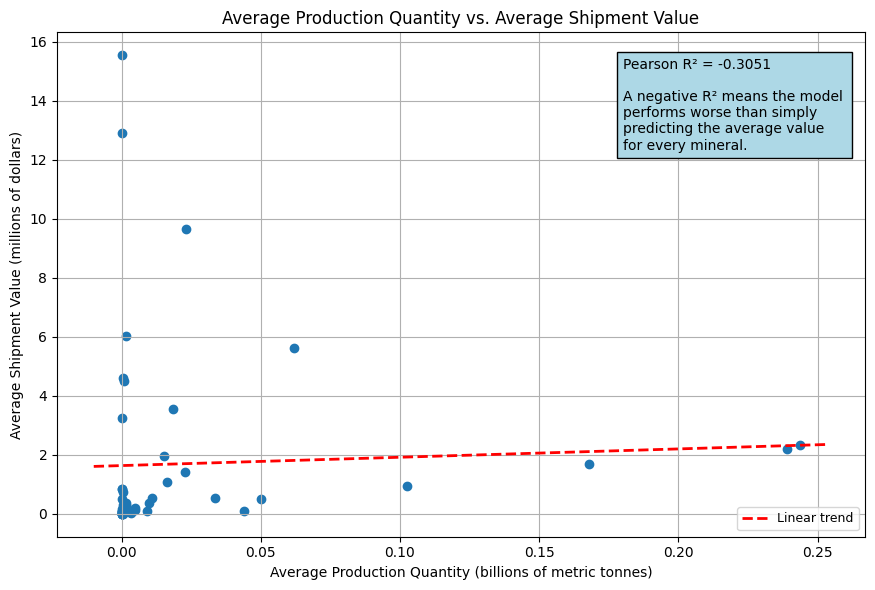

In [107]:
import matplotlib.pyplot as plt
import numpy as np

years = paired_df.index.values
total_qty = paired_df['AvgQuantity'].values / 1e9
total_val = paired_df['AvgValue'].values / 1e6

plt.figure(figsize=(9, 6))
plt.scatter(total_qty, total_val)



z = np.polyfit(total_qty, total_val, 1)
p = np.poly1d(z)
x_fit = np.linspace(total_qty.min() - 0.01, total_qty.max() + 0.01, 100)
plt.plot(x_fit, p(x_fit), '--', color='red', linewidth=2, label='Linear trend')

plt.text(0.7, 0.95,
         f'Pearson R² = {r2:.4f}\n\nA negative R² means the model \nperforms worse than simply \npredicting the average value \nfor every mineral.',
         transform=plt.gca().transAxes, fontsize=10, va='top', bbox=dict(fc='lightblue'))

plt.xlabel('Average Production Quantity (billions of metric tonnes)')
plt.ylabel('Average Shipment Value (millions of dollars)')
plt.title('Average Production Quantity vs. Average Shipment Value')
plt.gca().yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{x:.0f}'))
plt.grid(True)
plt.legend(fontsize=9, loc='lower right')
plt.tight_layout()
plt.show()